#Step 1 Mapeo origen fuente de datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Step 2 Importanto librerias

Aquí, importamos Image de PIL para trabajar con la imagen, openpyxl para manipular archivos de Excel y PatternFill para aplicar colores a las celdas de Excel.

In [2]:
# Importar las bibliotecas necesarias
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill

# Step 3 Funcion para procesar Imagen

Esta línea define la función image_to_excel con tres argumentos: image_path (ruta de la imagen JPG), excel_path (ruta del archivo Excel a guardar) y scale (factor de escala para la imagen, por defecto es 1, es decir, sin cambio de escala).

In [3]:
# Función para procesar la imagen
def procesar_imagen(ruta_imagen, tamano_maximo):
    # Cargar la imagen y redimensionar si es necesario
    with Image.open(ruta_imagen) as img:
        img.thumbnail(tamano_maximo)  # Redimensionar la imagen
        pixeles = list(img.getdata())  # Obtener los datos de los píxeles
        ancho, alto = img.size         # Obtener las dimensiones de la imagen
    return pixeles, ancho, alto       # Devolver los píxeles y dimensiones

In [4]:
# Función para crear y llenar la hoja de Excel
def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()          # Crear un nuevo libro de trabajo
    hoja = wb.active                  # Obtener la hoja activa

    # Recorrer los píxeles y aplicar el color a cada celda
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]                       # Obtener el color RGB
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"  # Convertir a hex
            celda = hoja.cell(row=y + 1, column=x + 1)           # Obtener la celda
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")

    return wb  # Devolver el libro de trabajo

# Función principal
def main():
    # Actualiza esta ruta a la ubicación de tu imagen en Google Drive
    ruta_imagen = "/content/drive/MyDrive/Imagen sistemas/spiderman negro 3.jpg"  # Ejemplo: "/content/drive/My Drive/Images/mi_imagen.jpg"
    tamano_maximo = (50, 50)

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)
    wb = crear_hoja_excel(pixeles, ancho, alto)

    # Guardar el archivo de Excel en Google Drive
    ruta_guardado = "/content/drive/MyDrive/Imagen sistemas/imagen_spiderman_v1.xlsx"  # Ejemplo: "/content/drive/My Drive/ExcelFiles/imagen_excel.xlsx"
    wb.save(ruta_guardado)

if __name__ == "__main__":
    main()


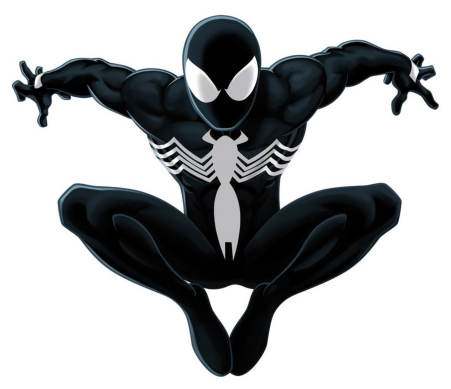

In [5]:
# prompt: quiero plotear la imagen que acabamos de procesar

from PIL import Image
import matplotlib.pyplot as plt

def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')  # Ocultar ejes
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

# Ejemplo de uso (reemplaza con la ruta correcta de tu imagen)
ruta_imagen = "/content/drive/MyDrive/Imagen sistemas/spiderman negro 3.jpg"
mostrar_imagen(ruta_imagen)


Iteracion v2


In [6]:
import openpyxl

def read_excel_colors(excel_path):
    """
    Reads an Excel file, extracts RGB color codes (from cell values or fill colors)
    from its cells, and returns a 2D list (matrix) of these color values.

    Args:
        excel_path (str): The path to the input Excel file.

    Returns:
        list[list[str]]: A 2D list (matrix) where each inner list represents a row
                         and contains hexadecimal color codes for each cell.
    """
    try:
        # Load the workbook from excel_path
        wb = openpyxl.load_workbook(excel_path)
        # Get the active worksheet from the loaded workbook
        ws = wb.active

        # Initialize an empty list of lists to store the extracted hex color codes
        colors_matrix = []

        # Iterate through each row in the worksheet
        for row in ws.iter_rows():
            row_colors = []
            # For each cell in the current row, get its color
            for cell in row:
                hex_color = 'FFFFFF' # Default to white if no color is found or parsed

                # Attempt to parse color from cell value first
                if cell.value is not None:
                    cell_value_str = str(cell.value).strip()

                    # Case 1: "R, G, B" or "R G B" format
                    if ',' in cell_value_str:
                        try:
                            r, g, b = map(int, cell_value_str.replace(' ', '').split(','))
                            if 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
                                hex_color = f"{r:02x}{g:02x}{b:02x}".upper()
                            else:
                                print(f"Warning: RGB values out of range in cell {cell.coordinate}: {cell_value_str}")
                        except ValueError:
                            pass # Not a valid "R, G, B" string
                    # Case 2: Hex string (e.g., 'FF0000' or '000000')
                    elif len(cell_value_str) == 6 and all(c in '0123456789ABCDEFabcdef' for c in cell_value_str):
                        hex_color = cell_value_str.upper()

                # Fallback: Check for existing cell fill color if value parsing failed or was empty
                if hex_color == 'FFFFFF' and cell.fill and cell.fill.start_color and cell.fill.start_color.rgb:
                    # Extract the RGB part (last 6 characters) from 'FFRRGGBB' or 'AARRGGBB'
                    hex_color = cell.fill.start_color.rgb[-6:].upper()

                row_colors.append(hex_color)
            # After processing all cells in a row, append row_colors to colors_matrix
            colors_matrix.append(row_colors)

        return colors_matrix
    except FileNotFoundError:
        print(f"Error: El archivo no fue encontrado en la ruta: {excel_path}")
        return None
    except Exception as e:
        print(f"Ocurrió un error al leer el archivo Excel: {e}")
        return None

print("The 'read_excel_colors' function has been defined.")

The 'read_excel_colors' function has been defined.


In [7]:
import openpyxl
from openpyxl.styles import PatternFill

def write_colors_to_excel(colors_matrix, output_excel_path):
    """
    Creates a new Excel file and fills its cells with the specified hexadecimal color codes.

    Args:
        colors_matrix (list[list[str]]): A 2D list (matrix) of hexadecimal color codes.
        output_excel_path (str): The path where the new Excel file will be saved.
    """
    try:
        wb = openpyxl.Workbook()  # Create a new workbook
        ws = wb.active            # Get the active worksheet

        # Iterate through the colors_matrix to fill cells
        for r_idx, row_colors in enumerate(colors_matrix):
            for c_idx, hex_color in enumerate(row_colors):
                # Ensure hex_color is a valid 6-digit hex string
                if hex_color and len(hex_color) == 6:
                    fill = PatternFill(start_color=hex_color, end_color=hex_color, fill_type="solid")
                    cell = ws.cell(row=r_idx + 1, column=c_idx + 1)
                    cell.fill = fill
                else:
                    # Optionally, handle invalid hex codes (e.g., set to white or skip)
                    pass

        # Adjust column widths and row heights for better visualization if needed
        # For simplicity, we'll skip complex auto-sizing here, but it could be added.
        # For example, to make cells square-ish for 'pixel art':
        # for col_idx in range(1, ws.max_column + 1):
        #     ws.column_dimensions[openpyxl.utils.get_column_letter(col_idx)].width = 2
        # for row_idx in range(1, ws.max_row + 1):
        #     ws.row_dimensions[row_idx].height = 12 # Roughly corresponds to width=2

        wb.save(output_excel_path) # Save the workbook
        print(f"Successfully created Excel file at: {output_excel_path}")
    except Exception as e:
        print(f"Error al escribir el archivo Excel: {e}")

print("The 'write_colors_to_excel' function has been defined.")

The 'write_colors_to_excel' function has been defined.


In [8]:
from google.colab import drive
import os

# Mount Google Drive if not already mounted
drive.mount('/content/drive')

# --- Define example usage ---

# IMPORTANT: Replace these paths with your actual input and desired output file paths
# Example input Excel file with hex color codes in cells
input_excel_path = '/content/drive/MyDrive/Imagen sistemas/imagen_excel_v2.xlsx'
# Example output Excel file where colored cells will be saved
output_excel_path = '/content/drive/MyDrive/Imagen sistemas/imagen_excel_v2.xlsx'

print(f"Attempting to read colors from: {input_excel_path}")
if not os.path.exists(input_excel_path):
    print(f"Error: Input file not found at {input_excel_path}. Please ensure the path is correct and the file exists.")
else:
    # 1. Read colors from the input Excel file
    colors_data = read_excel_colors(input_excel_path)

    if colors_data:
        print(f"Successfully read {len(colors_data)} rows of color data.")
        # 2. Write the colors to a new Excel file
        write_colors_to_excel(colors_data, output_excel_path)
    else:
        print("Failed to read color data from the input Excel file.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Attempting to read colors from: /content/drive/MyDrive/Imagen sistemas/imagen_excel_v2.xlsx
Successfully read 50 rows of color data.
Successfully created Excel file at: /content/drive/MyDrive/Imagen sistemas/imagen_excel_v2.xlsx


Iteración V3 mi imagen a matriz

In [9]:
# Step 1 Mapeo origen fuente de datos
from google.colab import drive
drive.mount('/content/drive')

# Step 2 Importando librerías
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill
import os

# Función para procesar la imagen
def procesar_imagen(ruta_imagen, tamano_maximo=None):
    try:
        with Image.open(ruta_imagen) as img:
            if tamano_maximo:
                img.thumbnail(tamano_maximo)  # Redimensionar la imagen si se proporciona un tamaño máximo
            pixeles = list(img.getdata())  # Obtener los datos de los píxeles
            ancho, alto = img.size         # Obtener las dimensiones de la imagen
        return pixeles, ancho, alto       # Devolver los píxeles y dimensiones
    except Exception as e:
        print(f"Error al procesar la imagen: {e}")
        return None, None, None

# Función para crear y llenar la hoja de Excel
def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()          # Crear un nuevo libro de trabajo
    hoja = wb.active                  # Obtener la hoja activa

    # Recorrer los píxeles y aplicar el color a cada celda
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]                       # Obtener el color RGB
            # color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"  # Convertir a hex
            celda = hoja.cell(row=y + 1, column=x + 1)           # Obtener la celda
            # celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid") # Comentado para no aplicar color
            celda.value = f"{color[0]}, {color[1]}, {color[2]}" # Asignar el valor numérico RGB a la celda

    return wb  # Devolver el libro de trabajo

# Función principal
def main():
    # Ruta de la imagen de Harry Potter
    ruta_imagen = "/content/drive/MyDrive/Imagen sistemas/spiderman negro 3.jpg"

    if not os.path.exists(ruta_imagen):
        print(f"Imagen no encontrada: {ruta_imagen}")
        return

    # Ajustar el tamaño máximo para que la imagen no exceda los límites de Excel
    tamano_maximo = (50, 50)  # Utilizando un tamaño más pequeño para la matriz RGB

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)

    if pixeles is None:
        print("No se pudo procesar la imagen.")
        return

    wb = crear_hoja_excel(pixeles, ancho, alto)

    # Ruta de guardado para el nuevo archivo Excel con solo los valores RGB
    ruta_guardado = "/content/drive/MyDrive/Imagen sistemas/Pixel_Spiderman_RGB.xlsx"

    try:
        wb.save(ruta_guardado)
        print(f"Archivo Excel con la matriz RGB guardado exitosamente en: {ruta_guardado}")
    except Exception as e:
        print(f"Error al guardar el archivo Excel: {e}")

if __name__ == "__main__":
    main()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo Excel con la matriz RGB guardado exitosamente en: /content/drive/MyDrive/Imagen sistemas/Pixel_Spiderman_RGB.xlsx


In [10]:
import openpyxl

def read_excel_colors(excel_path):
    """
    Reads an Excel file, extracts RGB color codes (from cell values or fill colors)
    from its cells, and returns a 2D list (matrix) of these color values.

    Args:
        excel_path (str): The path to the input Excel file.

    Returns:
        list[list[str]]: A 2D list (matrix) where each inner list represents a row
                         and contains hexadecimal color codes for each cell.
    """
    try:
        # Load the workbook from excel_path
        wb = openpyxl.load_workbook(excel_path)
        # Get the active worksheet from the loaded workbook
        ws = wb.active

        # Initialize an empty list of lists to store the extracted hex color codes
        colors_matrix = []

        # Iterate through each row in the worksheet
        for row in ws.iter_rows():
            row_colors = []
            # For each cell in the current row, get its color
            for cell in row:
                hex_color = 'FFFFFF' # Default to white if no color is found or parsed

                # Attempt to parse color from cell value first
                if cell.value is not None:
                    cell_value_str = str(cell.value).strip()

                    # Case 1: "R, G, B" or "R G B" format
                    if ',' in cell_value_str:
                        try:
                            r, g, b = map(int, cell_value_str.replace(' ', '').split(','))
                            if 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
                                hex_color = f"{r:02x}{g:02x}{b:02x}".upper()
                            else:
                                print(f"Warning: RGB values out of range in cell {cell.coordinate}: {cell_value_str}")
                        except ValueError:
                            pass # Not a valid "R, G, B" string
                    # Case 2: Hex string (e.g., 'FF0000' or '000000')
                    elif len(cell_value_str) == 6 and all(c in '0123456789ABCDEFabcdef' for c in cell_value_str):
                        hex_color = cell_value_str.upper()

                # Fallback: Check for existing cell fill color if value parsing failed or was empty
                if hex_color == 'FFFFFF' and cell.fill and cell.fill.start_color and cell.fill.start_color.rgb:
                    # Extract the RGB part (last 6 characters) from 'FFRRGGBB' or 'AARRGGBB'
                    hex_color = cell.fill.start_color.rgb[-6:].upper()

                row_colors.append(hex_color)
            # After processing all cells in a row, append row_colors to colors_matrix
            colors_matrix.append(row_colors)

        return colors_matrix
    except FileNotFoundError:
        print(f"Error: El archivo no fue encontrado en la ruta: {excel_path}")
        return None
    except Exception as e:
        print(f"Ocurrió un error al leer el archivo Excel: {e}")
        return None

print("The 'read_excel_colors' function has been defined.")

The 'read_excel_colors' function has been defined.


In [11]:
import openpyxl
from openpyxl.styles import PatternFill

def write_colors_to_excel(colors_matrix, output_excel_path):
    """
    Creates a new Excel file and fills its cells with the specified hexadecimal color codes.

    Args:
        colors_matrix (list[list[str]]): A 2D list (matrix) of hexadecimal color codes.
        output_excel_path (str): The path where the new Excel file will be saved.
    """
    try:
        wb = openpyxl.Workbook()  # Create a new workbook
        ws = wb.active            # Get the active worksheet

        # Iterate through the colors_matrix to fill cells
        for r_idx, row_colors in enumerate(colors_matrix):
            for c_idx, hex_color in enumerate(row_colors):
                # Ensure hex_color is a valid 6-digit hex string
                if hex_color and len(hex_color) == 6:
                    fill = PatternFill(start_color=hex_color, end_color=hex_color, fill_type="solid")
                    cell = ws.cell(row=r_idx + 1, column=c_idx + 1)
                    cell.fill = fill
                else:
                    # Optionally, handle invalid hex codes (e.g., set to white or skip)
                    pass

        # Adjust column widths and row heights for better visualization if needed
        # For simplicity, we'll skip complex auto-sizing here, but it could be added.
        # For example, to make cells square-ish for 'pixel art':
        # for col_idx in range(1, ws.max_column + 1):
        #     ws.column_dimensions[openpyxl.utils.get_column_letter(col_idx)].width = 2
        # for row_idx in range(1, ws.max_row + 1):
        #     ws.row_dimensions[row_idx].height = 12 # Roughly corresponds to width=2

        wb.save(output_excel_path) # Save the workbook
        print(f"Successfully created Excel file at: {output_excel_path}")
    except Exception as e:
        print(f"Error al escribir el archivo Excel: {e}")

print("The 'write_colors_to_excel' function has been defined.")

The 'write_colors_to_excel' function has been defined.


In [ ]:
from google.colab import drive
import os

# Mount Google Drive if not already mounted
drive.mount('/content/drive')

# --- Define example usage ---

# IMPORTANT: Replace these paths with your actual input and desired output file paths
# Example input Excel file with hex color codes in cells
input_excel_path = '/content/drive/MyDrive/Sistemasdeinfogerencial/Pixel_Harrypotter_RGB_Values.xlsx'
# Example output Excel file where colored cells will be saved
output_excel_path = '/content/drive/MyDrive/Sistemasdeinfogerencial/Pixel_Harrypotter_RGB_Values2.xlsx'

print(f"Attempting to read colors from: {input_excel_path}")
if not os.path.exists(input_excel_path):
    print(f"Error: Input file not found at {input_excel_path}. Please ensure the path is correct and the file exists.")
else:
    # 1. Read colors from the input Excel file
    colors_data = read_excel_colors(input_excel_path)

    if colors_data:
        print(f"Successfully read {len(colors_data)} rows of color data.")
        # 2. Write the colors to a new Excel file
        write_colors_to_excel(colors_data, output_excel_path)
    else:
        print("Failed to read color data from the input Excel file.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Attempting to read colors from: /content/drive/MyDrive/Sistemasdeinfogerencial/Pixel_Harrypotter_RGB_Values.xlsx
Error: Input file not found at /content/drive/MyDrive/Sistemasdeinfogerencial/Pixel_Harrypotter_RGB_Values.xlsx. Please ensure the path is correct and the file exists.


Codigo sin usar


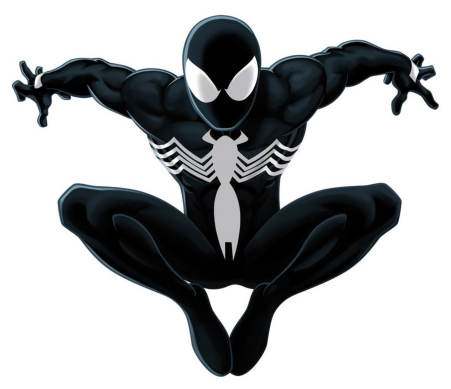

In [ ]:
# prompt: ahora quiero ver esta imagen en Pixeles que representa el output de nuestro scritp

import matplotlib.pyplot as plt
def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')  # Ocultar ejes
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

# Ejemplo de uso (reemplaza con la ruta correcta de tu imagen)
ruta_imagen = "/content/drive/MyDrive/Imagen sistemas/spiderman negro 3.jpg"
mostrar_imagen(ruta_imagen)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


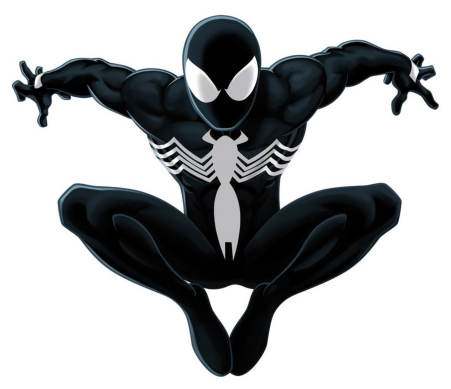

In [ ]:
# prompt: como puedo tener un resultado con menos pixeles?

from google.colab import drive
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill
import matplotlib.pyplot as plt

# Mount Google Drive
drive.mount('/content/drive')

def procesar_imagen(ruta_imagen, tamano_maximo):
    with Image.open(ruta_imagen) as img:
        img.thumbnail(tamano_maximo)
        pixeles = list(img.getdata())
        ancho, alto = img.size
    return pixeles, ancho, alto

def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()
    hoja = wb.active
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"
            celda = hoja.cell(row=y + 1, column=x + 1)
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")
    return wb

def main():
    ruta_imagen = "/content/drive/MyDrive/Imagen sistemas/spiderman negro 3.jpg"
    # Reduce the size for fewer pixels in the output Excel file
    tamano_maximo = (20, 20)  # Example: 20x20 pixels

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)
    wb = crear_hoja_excel(pixeles, ancho, alto)

    ruta_guardado = "/content/drive/MyDrive/Imagen sistemas/Pixel_Spiderman_v1_small.xlsx"
    wb.save(ruta_guardado)

if __name__ == "__main__":
    main()

def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

ruta_imagen = "/content/drive/MyDrive/Imagen sistemas/spiderman negro 3.jpg"
mostrar_imagen(ruta_imagen)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo Excel con la matriz RGB guardado exitosamente en: /content/drive/MyDrive/Sistemasdeinfogerencial/Pixel_Harrypotter_RGB_Values.xlsx


#SEGUNDA ITERACION

In [ ]:
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill

In [ ]:
def image_to_excel(image_path, excel_path, scale=1):
    # Cargar la imagen y escalar si es necesario
    img = Image.open(image_path)
    if scale != 1:
        img = img.resize((int(img.width * scale), int(img.height * scale)))

    img_rgb = img.convert('RGB')

    # Crear un nuevo archivo Excel
    wb = openpyxl.Workbook()
    ws = wb.active

    # Calcular dimensiones óptimas de las celdas basadas en la relación de aspecto de la imagen
    max_dim = 100  # Máxima dimensión para evitar celdas excesivamente grandes
    cell_width = max_dim / img.width
    cell_height = max_dim / img.height

    # Iterar sobre cada píxel de la imagen
    for i in range(img.width):
        for j in range(img.height):
            r, g, b = img_rgb.getpixel((i, j))
            hex_color = f"{r:02x}{g:02x}{b:02x}"
            fill = PatternFill(start_color=hex_color, end_color=hex_color, fill_type="solid")

            # Asignar el color al fondo de la celda correspondiente
            cell = ws.cell(row=j + 1, column=i + 1)
            cell.fill = fill

        # Ajustar el tamaño de las columnas y filas
        ws.column_dimensions[openpyxl.utils.get_column_letter(i+1)].width = cell_width
        for j in range(img.height):
            ws.row_dimensions[j+1].height = cell_height

    # Guardar el archivo Excel
    wb.save(excel_path)



In [ ]:
# Uso de la función con escala opcional
image_path = '/content/drive/MyDrive/Imagen sistemas/spiderman negro 3.jpg'  # Reemplazar con la ruta a tu imagen
excel_path = '/content/drive/MyDrive/Imagen sistemas/imagen_spiderman_v2.xlsx'  # Reemplazar con la ruta donde quieres guardar el Excel
scale = 0.5  # Escalar la imagen a la mitad de su tamaño original
image_to_excel(image_path, excel_path, scale)